# Copilot Suggestions: Advanced DecisionTreeRegressor Workflow

This notebook demonstrates best practices for using DecisionTreeRegressor with proper hyperparameter tuning, cross-validation, and model comparison.

## Table of Contents
1. [Setup & Data Loading](#setup)
2. [Baseline Decision Tree](#baseline)
3. [Improved Decision Tree with Better Hyperparameters](#improved)
4. [Hyperparameter Tuning with GridSearchCV](#gridsearch)
5. [Cross-Validation for Robust Evaluation](#crossval)
6. [Ensemble Methods Comparison](#ensemble)
7. [Feature Importance Analysis](#features)
8. [Final Recommendations](#recommendations)

## 1. Setup & Data Loading <a id='setup'></a>

First, let's import all necessary libraries and load the California housing dataset.

In [1]:
# Import essential libraries
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the California housing dataset
housing = fetch_california_housing()

# Create DataFrame for easier manipulation
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseValue")

print(f"Dataset shape: {X.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nTarget variable (y) range: ${y.min():.2f} to ${y.max():.2f}")
print("\nFirst few rows:")
X.head()

Dataset shape: (20640, 8)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target variable (y) range: $0.15 to $5.00

First few rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Check for data quality issues
print("Data Quality Check:")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")
print("\nFeature statistics:")
X.describe()

Data Quality Check:
Missing values in X: 0
Missing values in y: 0

Feature statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Train/Test split ratio: {X_train.shape[0] / X_test.shape[0]:.1f}:1")

Training set size: 16512 samples
Test set size: 4128 samples
Train/Test split ratio: 4.0:1


## 2. Baseline Decision Tree <a id='baseline'></a>

Let's start with your original approach - a simple DecisionTreeRegressor with only `max_depth` specified.

In [5]:
# Your original approach
baseline_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
baseline_dt.fit(X_train, y_train)

# Predictions
y_pred_train_baseline = baseline_dt.predict(X_train)
y_pred_test_baseline = baseline_dt.predict(X_test)

# Evaluation
train_r2_baseline = r2_score(y_train, y_pred_train_baseline)
test_r2_baseline = r2_score(y_test, y_pred_test_baseline)
train_mse_baseline = mean_squared_error(y_train, y_pred_train_baseline)
test_mse_baseline = mean_squared_error(y_test, y_pred_test_baseline)

print("=" * 60)
print("BASELINE MODEL (max_depth=5 only)")
print("=" * 60)
print(f"Training R²:  {train_r2_baseline:.4f}")
print(f"Test R²:      {test_r2_baseline:.4f}")
print(
	f"R² Gap:       {train_r2_baseline - test_r2_baseline:.4f} {'Overfitting!' if train_r2_baseline - test_r2_baseline > 0.1 else 'Good'}"
)
print(f"\nTraining MSE: {train_mse_baseline:.4f}")
print(f"Test MSE:     {test_mse_baseline:.4f}")

BASELINE MODEL (max_depth=5 only)
Training R²:  0.6377
Test R²:      0.5997
R² Gap:       0.0379 Good

Training MSE: 0.4843
Test MSE:     0.5245


## 3. Improved Decision Tree with Better Hyperparameters <a id='improved'></a>

Now let's add additional hyperparameters to prevent overfitting:
- `min_samples_split`: Minimum samples required to split an internal node
- `min_samples_leaf`: Minimum samples required in a leaf node
- `max_features`: Number of features to consider when looking for the best split

In [7]:
# Improved decision tree with regularization parameters
improved_dt = DecisionTreeRegressor(
	max_depth=5,
	min_samples_split=20,  # Require at least 20 samples to split
	min_samples_leaf=10,  # Require at least 10 samples in each leaf
	max_features="sqrt",  # Use sqrt of total features at each split
	random_state=42,
)

improved_dt.fit(X_train, y_train)

# Predictions
y_pred_train_improved = improved_dt.predict(X_train)
y_pred_test_improved = improved_dt.predict(X_test)

# Evaluation
train_r2_improved = r2_score(y_train, y_pred_train_improved)
test_r2_improved = r2_score(y_test, y_pred_test_improved)
train_mse_improved = mean_squared_error(y_train, y_pred_train_improved)
test_mse_improved = mean_squared_error(y_test, y_pred_test_improved)

print("=" * 60)
print("IMPROVED MODEL (with regularization)")
print("=" * 60)
print(f"Training R²:  {train_r2_improved:.4f}")
print(f"Test R²:      {test_r2_improved:.4f}")
print(
	f"R² Gap:       {train_r2_improved - test_r2_improved:.4f} {'Overfitting!' if train_r2_improved - test_r2_improved > 0.1 else 'Good'}"
)
print(f"\nTraining MSE: {train_mse_improved:.4f}")
print(f"Test MSE:     {test_mse_improved:.4f}")

# Compare with baseline
print("\n" + "=" * 60)
print("COMPARISON TO BASELINE")
print("=" * 60)
print(f"Test R² improvement:  {test_r2_improved - test_r2_baseline:+.4f}")
print(f"Test MSE improvement: {test_mse_baseline - test_mse_improved:+.4f}")
print(
	f"Overfitting reduction: {(train_r2_baseline - test_r2_baseline) - (train_r2_improved - test_r2_improved):.4f}"
)

IMPROVED MODEL (with regularization)
Training R²:  0.5282
Test R²:      0.5019
R² Gap:       0.0263 Good

Training MSE: 0.6307
Test MSE:     0.6527

COMPARISON TO BASELINE
Test R² improvement:  -0.0978
Test MSE improvement: -0.1282
Overfitting reduction: 0.0117


## 4. Hyperparameter Tuning with GridSearchCV <a id='gridsearch'></a>

Instead of guessing hyperparameters, let's systematically search for the best combination using GridSearchCV with cross-validation.

In [8]:
# Define parameter grid to search
param_grid = {
	"max_depth": [3, 5, 7, 10, 15],
	"min_samples_split": [10, 20, 50, 100],
	"min_samples_leaf": [5, 10, 20, 30],
	"max_features": ["sqrt", "log2", None],
}

print(
	f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations"
)
print(
	f"With 5-fold CV, this means {np.prod([len(v) for v in param_grid.values()]) * 5} model fits\n"
)

# Grid search with cross-validation
grid_search = GridSearchCV(
	estimator=DecisionTreeRegressor(random_state=42),
	param_grid=param_grid,
	cv=5,  # 5-fold cross-validation
	scoring="neg_mean_squared_error",  # Minimize MSE
	n_jobs=-1,  # Use all CPU cores
	verbose=2,  # Show progress
)

print("Starting GridSearchCV... This may take a minute...\n")
grid_search.fit(X_train, y_train)
print("\nGridSearchCV complete!")

Parameter grid size: 240 combinations
With 5-fold CV, this means 1200 model fits

Starting GridSearchCV... This may take a minute...

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

GridSearchCV complete!

GridSearchCV complete!


In [10]:
# Extract best model and parameters
best_dt = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_score = -grid_search.best_score_  # Negative because of neg_mean_squared_error

print("=" * 60)
print("BEST MODEL FOUND BY GRIDSEARCH")
print("=" * 60)
print("\nBest hyperparameters:")
for param, value in best_params.items():
	print(f"  {param}: {value}")

print(f"\nBest CV MSE: {best_cv_score:.4f}")

# Evaluate on test set
y_pred_train_best = best_dt.predict(X_train)
y_pred_test_best = best_dt.predict(X_test)

train_r2_best = r2_score(y_train, y_pred_train_best)
test_r2_best = r2_score(y_test, y_pred_test_best)
train_mse_best = mean_squared_error(y_train, y_pred_train_best)
test_mse_best = mean_squared_error(y_test, y_pred_test_best)

print(f"\nTraining R²:  {train_r2_best:.4f}")
print(f"Test R²:      {test_r2_best:.4f}")
print(f"R² Gap:       {train_r2_best - test_r2_best:.4f}")
print(f"\nTraining MSE: {train_mse_best:.4f}")
print(f"Test MSE:     {test_mse_best:.4f}")

BEST MODEL FOUND BY GRIDSEARCH

Best hyperparameters:
  max_depth: 15
  max_features: None
  min_samples_leaf: 10
  min_samples_split: 50

Best CV MSE: 0.3635

Training R²:  0.8169
Test R²:      0.7282
R² Gap:       0.0887

Training MSE: 0.2448
Test MSE:     0.3561


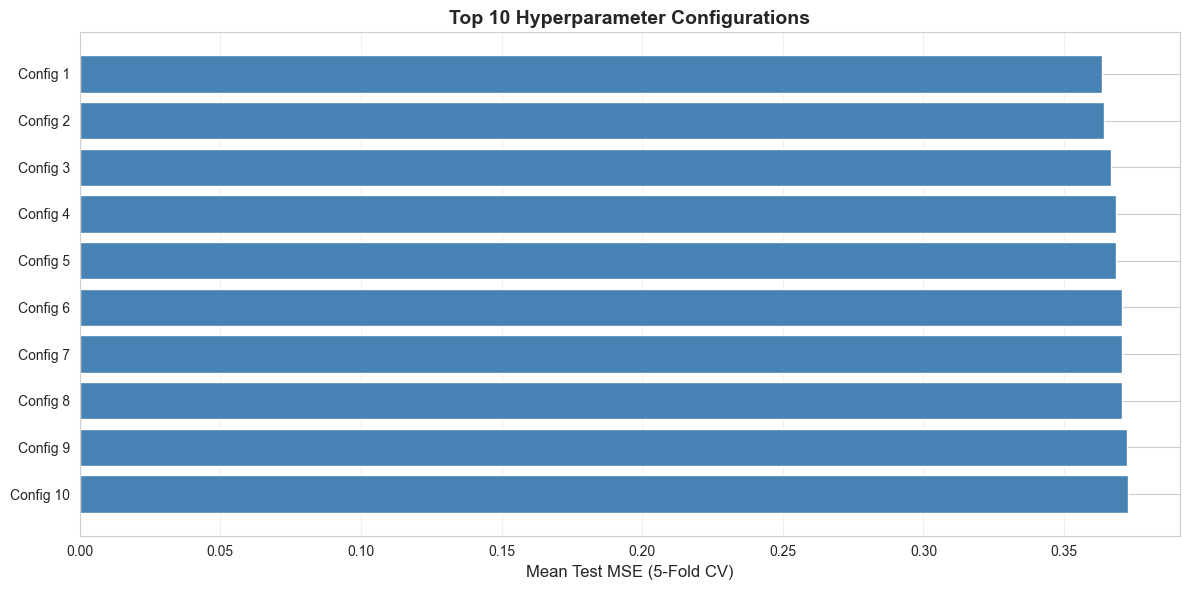


Top 5 configurations:

Rank 1:
  max_depth=15, min_samples_split=50, min_samples_leaf=10, max_features=None
  CV MSE: 0.3635

Rank 2:
  max_depth=15, min_samples_split=50, min_samples_leaf=5, max_features=None
  CV MSE: 0.3641

Rank 3:
  max_depth=15, min_samples_split=50, min_samples_leaf=20, max_features=None
  CV MSE: 0.3667

Rank 4:
  max_depth=15, min_samples_split=10, min_samples_leaf=20, max_features=None
  CV MSE: 0.3683

Rank 5:
  max_depth=15, min_samples_split=20, min_samples_leaf=20, max_features=None
  CV MSE: 0.3683


In [11]:
# Visualize top 10 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["mean_test_mse"] = -results_df["mean_test_score"]
results_df = results_df.sort_values("mean_test_mse").head(10)

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(results_df))
ax.barh(x_pos, results_df["mean_test_mse"], color="steelblue")
ax.set_yticks(x_pos)
ax.set_yticklabels([f"Config {i + 1}" for i in range(len(results_df))])
ax.set_xlabel("Mean Test MSE (5-Fold CV)", fontsize=12)
ax.set_title("Top 10 Hyperparameter Configurations", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 5 configurations:")
for idx, row in results_df.head(5).iterrows():
	print(f"\nRank {results_df.index.get_loc(idx) + 1}:")
	print(
		f"  max_depth={row['param_max_depth']}, "
		f"min_samples_split={row['param_min_samples_split']}, "
		f"min_samples_leaf={row['param_min_samples_leaf']}, "
		f"max_features={row['param_max_features']}"
	)
	print(f"  CV MSE: {row['mean_test_mse']:.4f}")

## 5. Cross-Validation for Robust Evaluation <a id='crossval'></a>

A single train/test split can be misleading. Let's use cross-validation to get a more robust estimate of model performance.

In [12]:
# Perform 10-fold cross-validation on the best model
cv_scores_mse = cross_val_score(
	best_dt, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1
)

cv_scores_r2 = cross_val_score(
	best_dt, X_train, y_train, cv=10, scoring="r2", n_jobs=-1
)

cv_scores_mae = cross_val_score(
	best_dt, X_train, y_train, cv=10, scoring="neg_mean_absolute_error", n_jobs=-1
)

print("=" * 60)
print("10-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"\nMSE: {-cv_scores_mse.mean():.4f} (+/- {cv_scores_mse.std():.4f})")
print(f"R²:  {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std():.4f})")
print(f"MAE: {-cv_scores_mae.mean():.4f} (+/- {cv_scores_mae.std():.4f})")
print("\n The +/- values show the standard deviation across folds")
print("  Lower standard deviation = more stable/reliable model")

10-FOLD CROSS-VALIDATION RESULTS

MSE: 0.3657 (+/- 0.0263)
R²:  0.7261 (+/- 0.0213)
MAE: 0.4046 (+/- 0.0146)

 The +/- values show the standard deviation across folds
  Lower standard deviation = more stable/reliable model


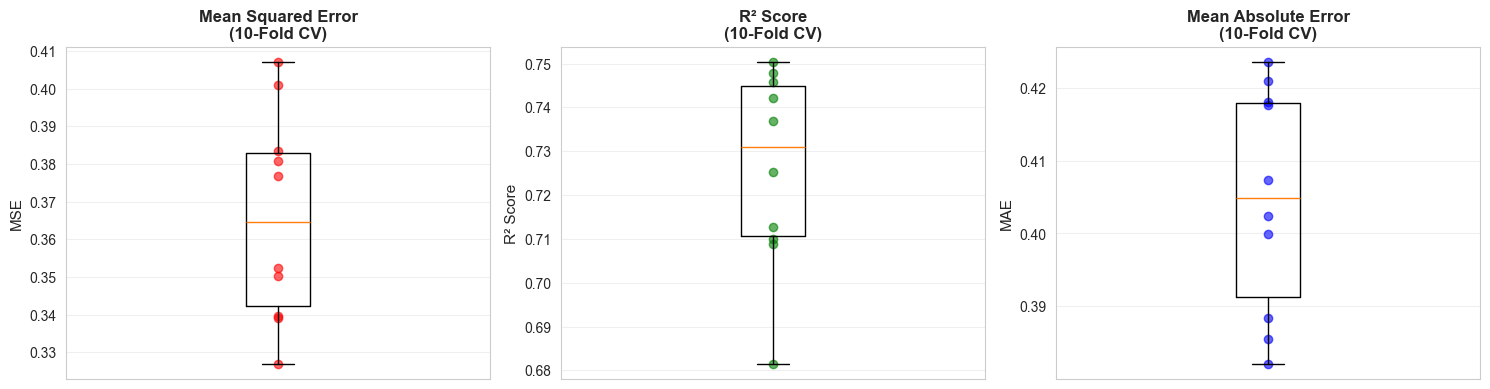

In [13]:
# Visualize cross-validation scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MSE
axes[0].boxplot(-cv_scores_mse)
axes[0].scatter([1] * len(cv_scores_mse), -cv_scores_mse, alpha=0.6, color="red")
axes[0].set_ylabel("MSE", fontsize=11)
axes[0].set_title("Mean Squared Error\n(10-Fold CV)", fontsize=12, fontweight="bold")
axes[0].set_xticks([])
axes[0].grid(axis="y", alpha=0.3)

# R²
axes[1].boxplot(cv_scores_r2)
axes[1].scatter([1] * len(cv_scores_r2), cv_scores_r2, alpha=0.6, color="green")
axes[1].set_ylabel("R² Score", fontsize=11)
axes[1].set_title("R² Score\n(10-Fold CV)", fontsize=12, fontweight="bold")
axes[1].set_xticks([])
axes[1].grid(axis="y", alpha=0.3)

# MAE
axes[2].boxplot(-cv_scores_mae)
axes[2].scatter([1] * len(cv_scores_mae), -cv_scores_mae, alpha=0.6, color="blue")
axes[2].set_ylabel("MAE", fontsize=11)
axes[2].set_title("Mean Absolute Error\n(10-Fold CV)", fontsize=12, fontweight="bold")
axes[2].set_xticks([])
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Ensemble Methods Comparison <a id='ensemble'></a>

Single decision trees have high variance. Let's compare with ensemble methods:
- **Random Forest**: Reduces variance through bagging (bootstrap aggregating)
- **Gradient Boosting**: Sequentially builds trees to correct previous errors

In [15]:
# Random Forest
rf_model = RandomForestRegressor(
	n_estimators=100,
	max_depth=10,
	min_samples_split=20,
	min_samples_leaf=10,
	max_features="sqrt",
	random_state=42,
	n_jobs=-1,
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
print("Random Forest trained")

# Gradient Boosting
gb_model = GradientBoostingRegressor(
	n_estimators=100,
	max_depth=3,
	learning_rate=0.1,
	min_samples_split=20,
	min_samples_leaf=10,
	random_state=42,
)

print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
gb_r2 = r2_score(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
print(" Gradient Boosting trained")

Training Random Forest...
Random Forest trained
Training Gradient Boosting...
Random Forest trained
Training Gradient Boosting...
 Gradient Boosting trained
 Gradient Boosting trained


In [16]:
# Create comparison DataFrame
comparison = pd.DataFrame({
	"Model": [
		"Baseline DT",
		"Improved DT",
		"Tuned DT",
		"Random Forest",
		"Gradient Boosting",
	],
	"Test R²": [test_r2_baseline, test_r2_improved, test_r2_best, rf_r2, gb_r2],
	"Test MSE": [test_mse_baseline, test_mse_improved, test_mse_best, rf_mse, gb_mse],
	"Overfitting Gap": [
		train_r2_baseline - test_r2_baseline,
		train_r2_improved - test_r2_improved,
		train_r2_best - test_r2_best,
		rf_model.score(X_train, y_train) - rf_r2,
		gb_model.score(X_train, y_train) - gb_r2,
	],
})

comparison = comparison.sort_values("Test R²", ascending=False)

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(comparison.to_string(index=False))
print("\n Lower MSE and higher R² are better")
print("Lower Overfitting Gap indicates better generalization")

MODEL COMPARISON
            Model  Test R²  Test MSE  Overfitting Gap
Gradient Boosting 0.776714  0.292596         0.027756
    Random Forest 0.755472  0.320432         0.052469
         Tuned DT 0.728218  0.356145         0.088656
      Baseline DT 0.599732  0.524515         0.037947
      Improved DT 0.501897  0.652719         0.026291

 Lower MSE and higher R² are better
Lower Overfitting Gap indicates better generalization


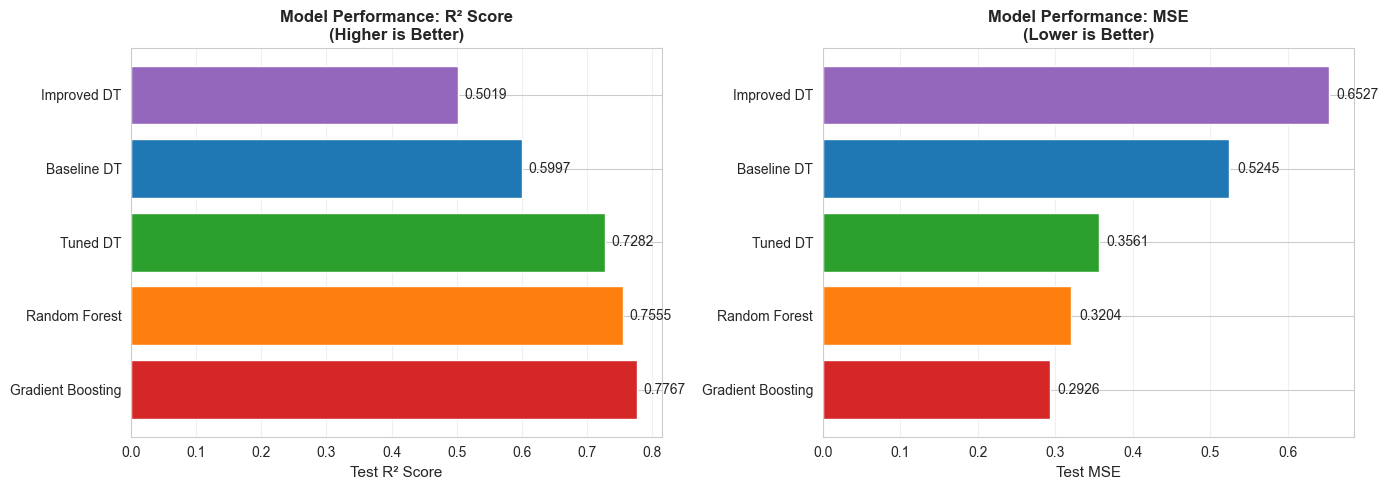

In [17]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]
axes[0].barh(comparison["Model"], comparison["Test R²"], color=colors)
axes[0].set_xlabel("Test R² Score", fontsize=11)
axes[0].set_title(
	"Model Performance: R² Score\n(Higher is Better)", fontsize=12, fontweight="bold"
)
axes[0].grid(axis="x", alpha=0.3)

# Add values on bars
for i, v in enumerate(comparison["Test R²"]):
	axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=10)

# MSE comparison
axes[1].barh(comparison["Model"], comparison["Test MSE"], color=colors)
axes[1].set_xlabel("Test MSE", fontsize=11)
axes[1].set_title(
	"Model Performance: MSE\n(Lower is Better)", fontsize=12, fontweight="bold"
)
axes[1].grid(axis="x", alpha=0.3)

# Add values on bars
for i, v in enumerate(comparison["Test MSE"]):
	axes[1].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis <a id='features'></a>

Let's examine which features are most important for predictions.

In [19]:
# Get feature importances from different models
feature_importance_df = pd.DataFrame({
	"Feature": X.columns,
	"Tuned DT": best_dt.feature_importances_,
	"Random Forest": rf_model.feature_importances_,
	"Gradient Boosting": gb_model.feature_importances_,
})

feature_importance_df = feature_importance_df.sort_values(
	"Random Forest", ascending=False
)

print("=" * 70)
print("FEATURE IMPORTANCE RANKINGS")
print("=" * 70)
print(feature_importance_df.to_string(index=False))

FEATURE IMPORTANCE RANKINGS
   Feature  Tuned DT  Random Forest  Gradient Boosting
    MedInc  0.620436       0.434542           0.602853
  AveRooms  0.036557       0.125934           0.022952
  Latitude  0.079700       0.122008           0.099287
  AveOccup  0.133397       0.121636           0.124605
 Longitude  0.068834       0.114886           0.111194
  HouseAge  0.045335       0.045928           0.032760
 AveBedrms  0.008816       0.024690           0.004393
Population  0.006925       0.010375           0.001956


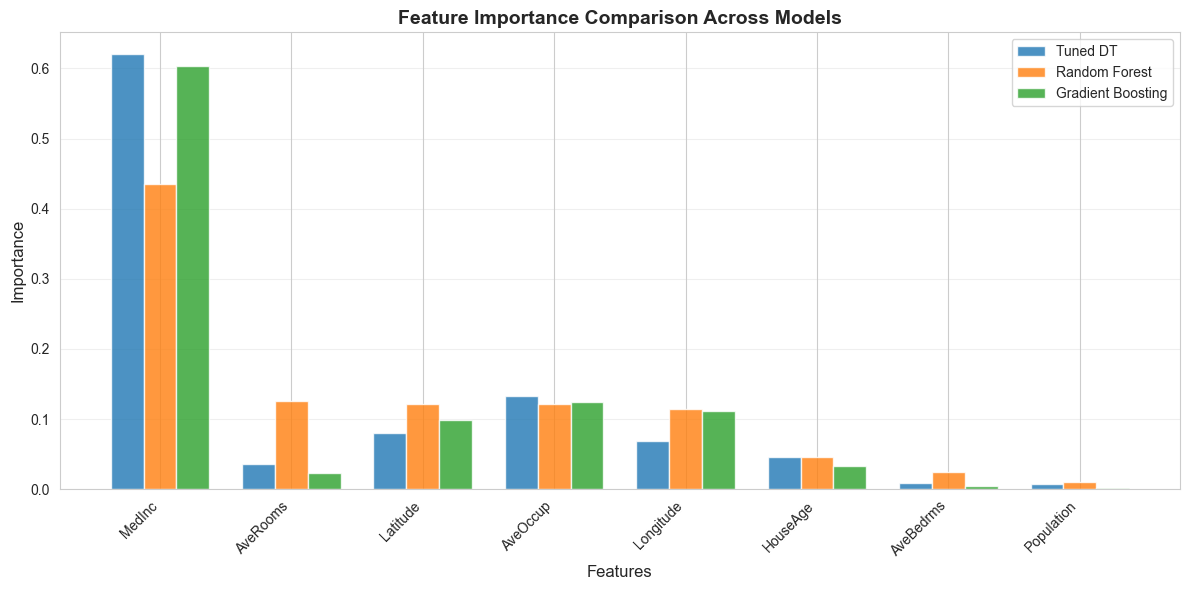

In [20]:
# Visualize feature importances
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(feature_importance_df))
width = 0.25

ax.bar(x - width, feature_importance_df["Tuned DT"], width, label="Tuned DT", alpha=0.8)
ax.bar(
	x, feature_importance_df["Random Forest"], width, label="Random Forest", alpha=0.8
)
ax.bar(
	x + width,
	feature_importance_df["Gradient Boosting"],
	width,
	label="Gradient Boosting",
	alpha=0.8,
)

ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Importance", fontsize=12)
ax.set_title(
	"Feature Importance Comparison Across Models", fontsize=14, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(feature_importance_df["Feature"], rotation=45, ha="right")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Final Recommendations <a id='recommendations'></a>

### Key Takeaways:

1. **Always use multiple hyperparameters**: Don't just rely on `max_depth`. Add `min_samples_split`, `min_samples_leaf`, and `max_features` to control overfitting.

2. **Use GridSearchCV or RandomizedSearchCV**: Systematically search for optimal hyperparameters rather than guessing.

3. **Employ cross-validation**: A single train/test split can be misleading. Use k-fold cross-validation for robust performance estimates.

4. **Consider ensemble methods**: Random Forests and Gradient Boosting usually outperform single decision trees.

5. **Monitor overfitting**: Track the gap between training and test performance. Large gaps indicate overfitting.

6. **Analyze feature importance**: Understanding which features matter helps with feature engineering and model interpretation.

### Best Practices for DecisionTreeRegressor:

```python
# Good starting point
dt = DecisionTreeRegressor(
    max_depth=5-10,           # Limit tree depth
    min_samples_split=20-50,  # Prevent splitting on small samples
    min_samples_leaf=10-20,   # Ensure leaves have enough samples
    max_features='sqrt',      # Add randomness to splits
    random_state=42           # Reproducibility
)
```

### When to use each model:

- **Single Decision Tree**: When interpretability is crucial and you need to explain predictions
- **Random Forest**: When you want better performance and can sacrifice some interpretability
- **Gradient Boosting**: When you need the best performance and have time for tuning

### Next Steps:

1. Try RandomizedSearchCV for faster hyperparameter tuning on larger grids
2. Experiment with feature engineering (creating new features)
3. Try advanced ensemble methods like XGBoost or LightGBM
4. Implement learning curves to diagnose bias vs. variance issues
5. Use SHAP values for better feature importance interpretation

In [21]:
# Summary of best model
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\n Best performing model: {comparison.iloc[0]['Model']}")
print(f"   Test R²: {comparison.iloc[0]['Test R²']:.4f}")
print(f"   Test MSE: {comparison.iloc[0]['Test MSE']:.4f}")
print(f"   Overfitting Gap: {comparison.iloc[0]['Overfitting Gap']:.4f}")

print("\nImprovement over baseline DecisionTreeRegressor:")
baseline_row = comparison[comparison["Model"] == "Baseline DT"].iloc[0]
best_row = comparison.iloc[0]
r2_improvement = (
	(best_row["Test R²"] - baseline_row["Test R²"]) / baseline_row["Test R²"]
) * 100
mse_improvement = (
	(baseline_row["Test MSE"] - best_row["Test MSE"]) / baseline_row["Test MSE"]
) * 100

print(f"   R² improvement: +{r2_improvement:.2f}%")
print(f"   MSE reduction: -{mse_improvement:.2f}%")

print("\nWorkflow complete!")

FINAL SUMMARY

 Best performing model: Gradient Boosting
   Test R²: 0.7767
   Test MSE: 0.2926
   Overfitting Gap: 0.0278

Improvement over baseline DecisionTreeRegressor:
   R² improvement: +29.51%
   MSE reduction: -44.22%

Workflow complete!
